# Model Iteration Notebook 

In this notebook, we will focus on training and evaluating multiple machine learning models to classify emotions in transcribed television show data. 

The different secitons in this notebook will help demonstrate how different models perform on the same dataset and will provide insights into model selection and optimization. 

For every type of model and/or iteration that we did, we tracked the details in the model iteration file that you can find attached to the final assignment on Brightspace or here [Model Iteration File](link-here). In order to improve our models, we used (a selection of) traditional NLP features that we extracted in the ‘NLP Features’ task [NLP Features.ipynb notebook](NLP Features.ipynb). 



In [1]:
# Configure logging to suppress INFO messages from different libraries
import logging
logging.basicConfig()
logger = logging.getLogger()
logger.setLevel(logging.WARNING)


In [2]:
import sys
import os

# Get the directory of the current notebook (which is /notebooks/)
# and navigate up one level (to /project_root/) to find /src
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))

# Add the project root to the system path
if project_root not in sys.path:
    sys.path.append(project_root)

# Now you can import as if you were in the project root
# For /src/processing/features.py, the module is src.processing.features
from src.processing import FeatureEngine
from src.predict import PredictEngine

c:\Users\rzvn1\.conda\envs\nlp_env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



In [3]:
import numpy as np
import pandas as pd
from typing import Dict
from collections import Counter
import json

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import LinearSVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score
from sklearn.preprocessing import normalize

import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
# Set Keras Backend to use PyTorch
os.environ["KERAS_BACKEND"] = "torch"
import keras
import torch 

print("Torch version:",torch.__version__)

print("Is CUDA enabled?",torch.cuda.is_available())

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

Torch version: 2.5.1
Is CUDA enabled? True


In [5]:
from keras import Model
from keras.models import load_model
from keras.layers import (Embedding, Dense, Concatenate,
                          SimpleRNN, LSTM, Input, Dropout)
from keras.callbacks import EarlyStopping
from keras.optimizers import Adam
from keras.utils import to_categorical

In [6]:
import tensorflow as tf

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import tokenizer_from_json

In [7]:
from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    TrainingArguments,
    Trainer,
    AutoConfig, 
    EarlyStoppingCallback
)
import evaluate

In [8]:
# Emotion Map obtained from https://aclanthology.org/I17-1099/ --> readme.txt
EMOTION_MAP: Dict[int, str] = {
    0: "neutral", 1: "anger", 2: "disgust", 3: "fear",
    4: "happiness", 5: "sadness", 6: "surprise"
}

In [9]:
df_concat = pd.read_csv(r"..\Data\CSV\sentiment_data\final_dataset.csv")

## Scikit-Learn Models

### Data preparation for scikit-learn

In [10]:
scikit_data = []
# Get unique emotions
unique_emotions = df_concat['Emotion'].unique()

# For each unique emotion, add 350 different rows
for emotion in unique_emotions:
    # Get all rows with this emotion
    emotion_rows = df_concat[df_concat['Emotion'] == emotion]
    
    # Sample 350 rows (with replacement if there are fewer than 350 available)
    sampled_rows = emotion_rows.sample(n=700, replace=True, random_state=42)
    
    # Add to the list
    scikit_data.append(sampled_rows)

# Create new dataframe by concatenating all sampled rows
scikit_data = pd.concat(scikit_data, ignore_index=True)

scikit_data['Emotion_ID'] = scikit_data['Emotion_ID'].astype(int)

scikit_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4900 entries, 0 to 4899
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  4900 non-null   int64 
 1   Sentence    4900 non-null   object
 2   Emotion     4900 non-null   object
 3   Emotion_ID  4900 non-null   int32 
dtypes: int32(1), int64(1), object(2)
memory usage: 134.1+ KB


In [11]:
scikit_data['Sentence'].nunique()
scikit_data.drop_duplicates(subset=['Sentence'], inplace=True)

In [12]:
features = FeatureEngine(custom_embeddings_path=r'..\Data\CSV\Yelp Restaurant Reviews.csv')
results = features.create_features(transcript_df_input=scikit_data, output_path=None)

In [13]:
scikit_df = results.copy()

In [14]:
scikit_df.head()

,Unnamed: 0,Sentence,Emotion,Emotion_ID,POS_tags,Sentiment,TF-IDF,word2vec_embedding,custom_word2vec_embedding,bert_embedding
0,131607,i think the fact that i am feeling a little ap...,fear,3,"[(i, NOUN), (think, VERB), (the, DET), (fact, ...",0.137500,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[-0.0067983773, 0.028879605, 0.0091975285, 0.0...","[-0.0736747, 0.11745935, 0.057716258, 0.026673...","[0.26444843, 0.39232564, 0.06754342, -0.534239..."
1,6835,i started feeling terrified,fear,3,"[(i, NOUN), (started, VERB), (feeling, VERB), ...",0.000000,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.030395508, 0.08758545, 0.0077209473, 0.0012...","[-0.08036971, 0.37200895, 0.058732197, 0.11663...","[0.12794185, 0.13075173, 0.14813915, -0.064277..."
2,330814,i feel for all of the victims and their famili...,fear,3,"[(i, NOUN), (feel, VERB), (for, ADP), (all, DE...",0.166667,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.010828191, 0.02356512, 0.010276101, 0.12585...","[-0.0075227534, 0.1623888, 0.03758243, 0.11859...","[-0.06701388, 0.14782472, 0.12844124, -0.26227..."
3,506845,I’m afraid of the dark.,fear,3,"[(I, PRON), (’, VERB), (m, ADJ), (afraid, NOUN...",-0.375000,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.1953125, 0.08569336, 0.13183594, 0.0579834,...","[-0.11375392, 0.0057538203, -0.057569742, 0.21...","[0.30258685, 0.33086362, -0.35033846, -0.45129..."
4,93206,i feel pretty shy about the students but i thi...,fear,3,"[(i, NOUN), (feel, VERB), (pretty, ADV), (shy,...",0.170833,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.029205322, 0.029956818, 0.04335022, 0.12544...","[-0.097411856, 0.07417727, -0.009542086, 0.115...","[0.28519934, 0.10159663, 0.25914514, -0.241023..."


In [15]:
scikit_df = scikit_df.drop(columns=['Emotion', 'POS_tags','TF-IDF', 'Sentence','Unnamed: 0'])

In [16]:
scikit_df['Sentiment'] = scikit_df['Sentiment'].values.reshape(-1, 1)
scikit_df['word2vec_embedding'] = np.vstack(scikit_df['word2vec_embedding'].values)
scikit_df['bert_embedding'] = np.vstack(scikit_df['bert_embedding'].values)
scikit_df['custom_word2vec_embedding'] = np.vstack(scikit_df['custom_word2vec_embedding'].values)

In [17]:
scikit_df.head()

,Emotion_ID,Sentiment,word2vec_embedding,custom_word2vec_embedding,bert_embedding
0,3,0.137500,-0.006798,-0.073675,0.264448
1,3,0.000000,0.030396,-0.080370,0.127942
2,3,0.166667,0.010828,-0.007523,-0.067014
3,3,-0.375000,0.195312,-0.113754,0.302587
4,3,0.170833,0.029205,-0.097412,0.285199


In [18]:
# Initialize empty dict for storing predictions
predictions = {}

### Logistic Regression

In [19]:
log_reg = LogisticRegression(max_iter=3000, penalty='elasticnet', random_state=42, solver='saga', l1_ratio=0.5)
X = scikit_df.drop(columns=['Emotion_ID'])
y = scikit_df['Emotion_ID']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

log_reg.fit(X_train, y_train)
y_pred = log_reg.predict(X_test)
predictions["Logistic Regression"] = y_pred

print(classification_report(y_test, y_pred, digits=3, target_names=EMOTION_MAP.values()))


              precision    recall  f1-score   support

     neutral      0.215     0.438     0.288       121
       anger      0.195     0.211     0.203       123
     disgust      0.299     0.268     0.283       142
        fear      0.000     0.000     0.000       158
   happiness      0.379     0.594     0.463       143
     sadness      0.191     0.210     0.200       138
    surprise      0.238     0.141     0.177       142

    accuracy                          0.260       967
   macro avg      0.217     0.266     0.231       967
weighted avg      0.214     0.260     0.226       967



c:\Users\rzvn1\.conda\envs\nlp_env\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\rzvn1\.conda\envs\nlp_env\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\rzvn1\.conda\envs\nlp_env\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0]

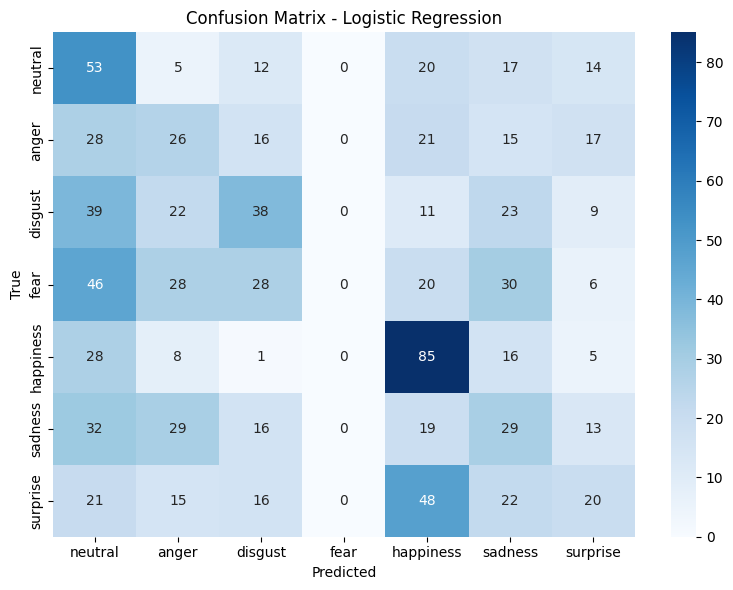

In [20]:
# Get predictions from log_reg
y_pred = log_reg.predict(X_test)

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot heatmap
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[EMOTION_MAP[i] for i in range(len(EMOTION_MAP))],
            yticklabels=[EMOTION_MAP[i] for i in range(len(EMOTION_MAP))],
            ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_title('Confusion Matrix - Logistic Regression')
plt.tight_layout()
plt.show()

In [21]:
nb = GaussianNB(var_smoothing=2)
nb.fit(X_train, y_train)
y_pred = nb.predict(X_test)
predictions["Naive Bayes"] = y_pred

print(classification_report(y_test, y_pred,digits=3, target_names=EMOTION_MAP.values()))

              precision    recall  f1-score   support

     neutral      0.162     0.653     0.259       121
       anger      0.149     0.268     0.191       123
     disgust      0.636     0.099     0.171       142
        fear      0.000     0.000     0.000       158
   happiness      0.345     0.559     0.427       143
     sadness      0.000     0.000     0.000       138
    surprise      0.000     0.000     0.000       142

    accuracy                          0.213       967
   macro avg      0.185     0.226     0.150       967
weighted avg      0.184     0.213     0.145       967



c:\Users\rzvn1\.conda\envs\nlp_env\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\rzvn1\.conda\envs\nlp_env\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\rzvn1\.conda\envs\nlp_env\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0]

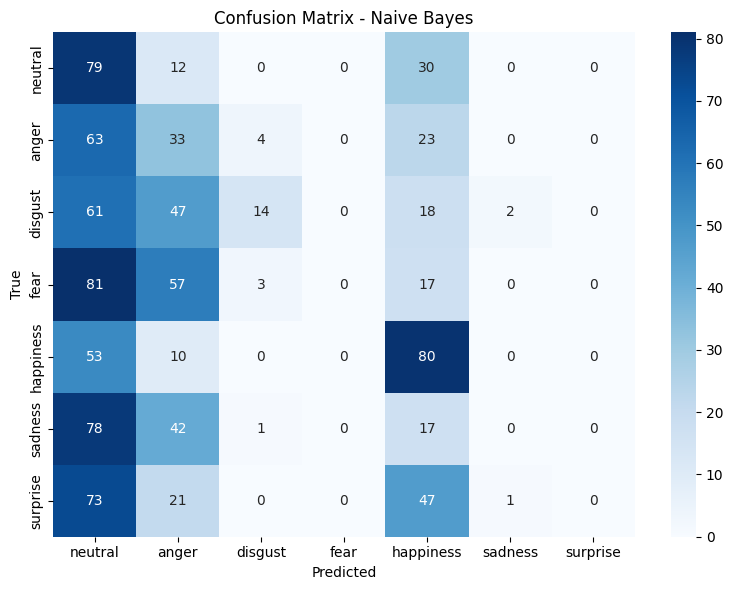

In [22]:
# Get predictions from Naive Bayes
y_pred = nb.predict(X_test)

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot heatmap
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[EMOTION_MAP[i] for i in range(len(EMOTION_MAP))],
            yticklabels=[EMOTION_MAP[i] for i in range(len(EMOTION_MAP))],
            ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_title('Confusion Matrix - Naive Bayes')
plt.tight_layout()
plt.show()

In [23]:
svc = LinearSVC(penalty='l2', loss='squared_hinge', C=2000.0, multi_class='ovr', fit_intercept=True, random_state=42, dual=True, max_iter=30000)
svc.fit(X_train, y_train)

y_pred = svc.predict(X_test)
predictions["SVC"] = y_pred
print(classification_report(y_test, y_pred,digits=3, target_names=EMOTION_MAP.values()))

              precision    recall  f1-score   support

     neutral      0.210     0.380     0.271       121
       anger      0.219     0.171     0.192       123
     disgust      0.250     0.282     0.265       142
        fear      0.000     0.000     0.000       158
   happiness      0.309     0.671     0.423       143
     sadness      0.146     0.145     0.145       138
    surprise      0.182     0.056     0.086       142

    accuracy                          0.239       967
   macro avg      0.188     0.244     0.197       967
weighted avg      0.184     0.239     0.193       967



c:\Users\rzvn1\.conda\envs\nlp_env\lib\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
c:\Users\rzvn1\.conda\envs\nlp_env\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\rzvn1\.conda\envs\nlp_env\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\rzvn1\.conda\envs\nlp_env\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and bei

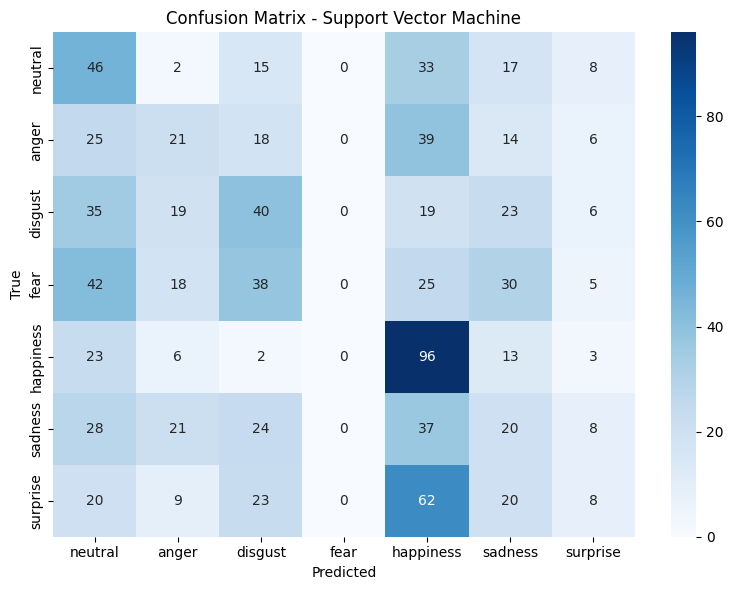

In [24]:
# Get predictions from Support Vector Machine
y_pred = svc.predict(X_test)

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot heatmap
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[EMOTION_MAP[i] for i in range(len(EMOTION_MAP))],
            yticklabels=[EMOTION_MAP[i] for i in range(len(EMOTION_MAP))],
            ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_title('Confusion Matrix - Support Vector Machine')
plt.tight_layout()
plt.show()

In [25]:
TRUE_SKLEARN = y_test
SK_TEST = X_test

### Error analysis on Scikit-learn models 

In [26]:
# Define which models use sklearn-style data
sklearn_models = ["Logistic Regression", "Naive Bayes", "SVC"]

for model_name, y_pred in predictions.items():
    if model_name in sklearn_models:
        f1 = f1_score(TRUE_SKLEARN, y_pred, average='weighted')  # sklearn y_test
    else:
        raise ValueError(f"Unknown model name: {model_name}.")
    
    print(f"The {model_name} model yielded a weighted F1 score of: {f1:.3f}")


The Logistic Regression model yielded a weighted F1 score of: 0.226
The Naive Bayes model yielded a weighted F1 score of: 0.145
The SVC model yielded a weighted F1 score of: 0.193


In [27]:
def error_analysis(predictions, model_group, X_test_data, y_true, label_map):
    results = {}
    all_errors = []

    for model_name in model_group:
        if model_name not in predictions:
            continue

        y_pred = predictions[model_name]

        # Convert both to numpy arrays for safe comparison
        y_true_np = y_true.to_numpy() if isinstance(y_true, pd.Series) else np.array(y_true)
        y_pred_np = y_pred.to_numpy() if isinstance(y_pred, pd.Series) else np.array(y_pred)

        # Find mismatches
        mismatches = np.where(y_true_np != y_pred_np)[0]

        mismatched_examples = []
        for i in mismatches[:10]:
            # X_test_data row
            x_row = X_test_data.iloc[i] if isinstance(X_test_data, pd.DataFrame) else X_test_data[i]
            # Convert labels to human-readable names
            true_val = label_map[y_true_np[i]]
            pred_val = label_map[y_pred_np[i]]
            mismatched_examples.append((x_row, true_val, pred_val))

        results[model_name] = {
            "num_errors": len(mismatches),
            "total": len(y_true),
            "error_rate": len(mismatches) / len(y_true),
            "mismatched_indices": mismatches,
            "mismatched_examples": mismatched_examples
        }

        # Aggregate common mistakes using label names
        for i in mismatches:
            true_val = label_map[y_true_np[i]]
            pred_val = label_map[y_pred_np[i]]
            all_errors.append((true_val, pred_val))

    # Aggregate common mistakes
    most_common_errors = Counter(all_errors).most_common(10)

    return results, most_common_errors

In [28]:
sk_results, sk_common_errors = error_analysis(predictions, sklearn_models, SK_TEST, TRUE_SKLEARN, EMOTION_MAP)

# Display results in defined order
print("Scikit-learn models error stats:")
for model in sklearn_models:  
    if model in sk_results:
        stats = sk_results[model]
        print(f"{model}: {stats['num_errors']} errors out of {stats['total']} ({stats['error_rate']:.2%})")

print("\nMost common sklearn mistakes (true → predicted):")
for item in sk_common_errors:
    print(item)

Scikit-learn models error stats:
Logistic Regression: 716 errors out of 967 (74.04%)
Naive Bayes: 761 errors out of 967 (78.70%)
SVC: 736 errors out of 967 (76.11%)

Most common sklearn mistakes (true → predicted):
(('fear', 'neutral'), 169)
(('surprise', 'happiness'), 157)
(('sadness', 'neutral'), 138)
(('disgust', 'neutral'), 135)
(('anger', 'neutral'), 116)
(('surprise', 'neutral'), 114)
(('happiness', 'neutral'), 104)
(('fear', 'anger'), 103)
(('sadness', 'anger'), 92)
(('disgust', 'anger'), 88)


- **Logistic Regression**
    - Even when applying multiple iterations and improvements to Logistic Regression, the highest F1-score achieved was only around 25% for 6 classes. 

    - Looking at the confusion matrix of Logistic Regression, it is doing somewhat decent on classifying neutral, disgust and happiness. 

    - It is doing particularly bad on fear, where it only predicted one instance of fear correctly and most of the fear class was predicted into ___neutral, anger, disgust and surprise___

- **Naive Bayes**
    - Same case as with Logistic Regression. After many interations the best achieved F1-score was 27%.

    - This model is doing well on neutral, happiness and then somewhat good on disgust and fear. 

    - The biggest issue is, that it predcts everything as neutral for most cases, with many sadness classes being predicted as neutral and none as sadness

- **Support Vector Machine**
    - Support Vector Machine was achieving the worst reuslts among these three, achieving only 22% F1-score at best. 

    - This model is doing the best on happiness. It classifies happiness 49 out of 70. Also it is doing somewhat good on disgust.

    - But as is was case with the Logistic Regression, it is doing really bad on fear and sadness.

*Scikit-Learn overall statistic*

All of the models have more than **70%** error rate. The most troubling class is happiness with having most errors in ***surprise, anger, sadness and neutral***. 

Next problematic class is neutral. Not as problematic as happiness, but it is right behind it. This may suggest that the models fail to correctly distinguish fear and anger from neutral, even though when these should be clearly separate. We come to the conclusion, that scikit-learn models are not suitable for this task


## Keras Models

### Data Preparation for the Keras models

In [29]:
keras_data = []
# Get unique emotions
unique_emotions = df_concat['Emotion'].unique()

# For each unique emotion, add 350 different rows
for emotion in unique_emotions:
    # Get all rows with this emotion
    emotion_rows = df_concat[df_concat['Emotion'] == emotion]
    
    # Sample 350 rows (with replacement if there are fewer than 350 available)
    sampled_rows = emotion_rows.sample(n=1000, replace=True, random_state=42)
    
    # Add to the list
    keras_data.append(sampled_rows)

# Create new dataframe by concatenating all sampled rows
keras_data = pd.concat(keras_data, ignore_index=True)
keras_data['Emotion_ID'] = keras_data['Emotion_ID'].astype(int)

keras_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7000 entries, 0 to 6999
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  7000 non-null   int64 
 1   Sentence    7000 non-null   object
 2   Emotion     7000 non-null   object
 3   Emotion_ID  7000 non-null   int32 
dtypes: int32(1), int64(1), object(2)
memory usage: 191.5+ KB


In [30]:
keras_data['Sentence'].nunique()
keras_data.drop_duplicates(subset=['Sentence'], inplace=True)

In [31]:
features = FeatureEngine(custom_embeddings_path=r'..\Data\CSV\Yelp Restaurant Reviews.csv')

keras_df = features.create_features(transcript_df_input=keras_data, output_path=None)

In [32]:
keras_df.drop(columns='Unnamed: 0', inplace=True)

In [33]:
keras_df.head()

,Sentence,Emotion,Emotion_ID,POS_tags,Sentiment,TF-IDF,word2vec_embedding,custom_word2vec_embedding,bert_embedding
0,i think the fact that i am feeling a little ap...,fear,3,"[(i, NOUN), (think, VERB), (the, DET), (fact, ...",0.137500,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[-0.0067983773, 0.028879605, 0.0091975285, 0.0...","[-0.0736747, 0.11745935, 0.057716258, 0.026673...","[0.26444843, 0.39232564, 0.06754342, -0.534239..."
1,i started feeling terrified,fear,3,"[(i, NOUN), (started, VERB), (feeling, VERB), ...",0.000000,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.030395508, 0.08758545, 0.0077209473, 0.0012...","[-0.08036971, 0.37200895, 0.058732197, 0.11663...","[0.12794185, 0.13075173, 0.14813915, -0.064277..."
2,i feel for all of the victims and their famili...,fear,3,"[(i, NOUN), (feel, VERB), (for, ADP), (all, DE...",0.166667,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.010828191, 0.02356512, 0.010276101, 0.12585...","[-0.0075227534, 0.1623888, 0.03758243, 0.11859...","[-0.06701388, 0.14782472, 0.12844124, -0.26227..."
3,I’m afraid of the dark.,fear,3,"[(I, PRON), (’, VERB), (m, ADJ), (afraid, NOUN...",-0.375000,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.1953125, 0.08569336, 0.13183594, 0.0579834,...","[-0.11375392, 0.0057538203, -0.057569742, 0.21...","[0.30258685, 0.33086362, -0.35033846, -0.45129..."
4,i feel pretty shy about the students but i thi...,fear,3,"[(i, NOUN), (feel, VERB), (pretty, ADV), (shy,...",0.170833,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.029205322, 0.029956818, 0.04335022, 0.12544...","[-0.097411856, 0.07417727, -0.009542086, 0.115...","[0.28519934, 0.10159663, 0.25914514, -0.241023..."


In [34]:
keras_df = keras_df.drop(columns=['Emotion', 'POS_tags','TF-IDF'])

In [35]:
X = keras_df.drop(columns=['Emotion_ID'])
y = keras_df['Emotion_ID']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [36]:
X_train.shape, X_test.shape

((5498, 5), (1375, 5))

In [37]:
try:
    with open('artifacts/keras_tok/tokenizer.json', 'r', encoding='utf-8') as f:
        loaded_tokenizer_json_str = f.read()
    inner_tokenizer_json_str = json.loads(loaded_tokenizer_json_str)
    tokenizer = tokenizer_from_json(inner_tokenizer_json_str)

    print("Tokenizer loaded successfully.")
except:
    tokenizer = Tokenizer(filters='')
    tokenizer.fit_on_texts(X_train['Sentence'])
    print('Fitted a new Tokenizer object')

Tokenizer loaded successfully.


In [38]:
# Define the directory path and the full file path
output_dir = 'artifacts\keras_tok'
file_path = os.path.join(output_dir, 'tokenizer.json')

# 1. Create the directory if it does not exist
os.makedirs(output_dir, exist_ok=True)

# 2. Proceed with saving the tokenizer
tokenizer_json = tokenizer.to_json()

with open(file_path, 'w', encoding='utf-8') as f:
    f.write(json.dumps(tokenizer_json, ensure_ascii=False))

print(f"Tokenizer saved to {file_path}")

Tokenizer saved to artifacts\keras_tok\tokenizer.json


In [39]:
V = len(tokenizer.word_index)
V

9924

In [40]:
train_tok = tokenizer.texts_to_sequences(X_train['Sentence'])
test_tok = tokenizer.texts_to_sequences(X_test['Sentence'])

In [41]:
train_padded = pad_sequences(train_tok,
              padding='post',
              maxlen=30)

test_padded = pad_sequences(test_tok,
              padding='post',
              maxlen=30)


In [42]:
X_train['Sentence_Tok'] = train_padded.tolist()
X_test['Sentence_Tok'] = test_padded.tolist()

In [43]:
X_train.drop(columns='Sentence', inplace=True)
X_test.drop(columns='Sentence', inplace=True)

In [44]:
y_train = to_categorical(y_train, num_classes=7)
y_test = to_categorical(y_test, num_classes=7)

In [45]:
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((5498, 5), (5498, 7), (1375, 5), (1375, 7))

In [46]:
X_train.head()

,Sentiment,word2vec_embedding,custom_word2vec_embedding,bert_embedding,Sentence_Tok
4688,0.20,"[0.029514018, 0.015031081, 0.016991835, 0.1229...","[-0.13586524, 0.092669524, 0.02727731, 0.13066...","[0.24796142, 0.15772775, 0.041748233, -0.34366...","[1, 5, 18, 2, 60, 1, 19, 24, 2, 677, 15, 63, 4..."
5693,0.00,"[0.07672119, -0.006591797, 0.04321289, 0.08046...","[-0.048823178, 0.09958739, 0.1290431, 0.109608...","[0.086479805, -0.015461787, -0.3460927, 0.2454...","[128, 25, 1542, 4162, 170, 2, 884, 40, 0, 0, 0..."
2134,0.00,"[0.04073819, 0.02465959, 0.081809305, 0.135409...","[-0.00814388, 0.07418035, -0.03169415, 0.15431...","[0.037790444, -0.009430461, 0.2575016, -0.2049...","[1, 33, 4163, 32, 2807, 1, 252, 75, 2808, 973,..."
252,0.00,"[0.012212117, 0.040827435, -0.017425537, 0.117...","[-0.036882818, 0.039980486, -0.046552885, 0.06...","[-0.074894674, 0.30284852, -0.14308092, -0.360...","[1, 27, 90, 4165, 4, 4166, 313, 5, 1, 27, 98, ..."
2666,0.35,"[0.033184346, -0.00034038836, 0.024799053, 0.1...","[-0.028520243, 0.05786729, -0.048829213, 0.121...","[-0.1280152, 0.06455885, 0.061843384, 0.077798...","[1, 5, 63, 1090, 3, 30, 322, 3, 4167, 4168, 13..."


In [47]:
X_train_toks = X_train['Sentence_Tok']
X_test_toks = X_test['Sentence_Tok']

In [48]:
X_train_toks =  np.array(X_train_toks.tolist())
X_test_toks = np.array(X_test_toks.tolist()) 

In [49]:
X_train_features = np.hstack([
    np.stack(X_train["word2vec_embedding"].to_numpy()),
    np.stack(X_train["bert_embedding"].to_numpy())
])

X_test_features = np.hstack([
    np.stack(X_test["word2vec_embedding"].to_numpy()),
    np.stack(X_test["bert_embedding"].to_numpy())
])

In [50]:
bert_train = normalize(np.stack(X_train["bert_embedding"].to_numpy()))
bert_test = normalize(np.stack(X_test["bert_embedding"].to_numpy()))

In [51]:
X_train_toks.shape, X_test_toks.shape

((5498, 30), (1375, 30))

### RNN Model

#### One recurrent layer

In [52]:
tokens_input = Input(shape=(30,), name="tokens_input")
x = Embedding(input_dim=V+1, output_dim=128)(tokens_input)
x = SimpleRNN(128, activation="tanh", return_sequences=False)(x)  # final hidden state

# 4. Classification head
dense = Dense(64, activation="relu", kernel_regularizer="l2")(x)
dense = Dense(128, activation="relu", kernel_regularizer="l2")(dense)
dense = Dropout(0.4)(dense)
output = Dense(7, activation="softmax")(dense)

# 5. Build model
model = Model(inputs=tokens_input, outputs=output, name='SimpleRNN-v0')
model.compile(optimizer=Adam(learning_rate=1e-4), loss='categorical_crossentropy', metrics=['accuracy'])

In [53]:
try:
    model = load_model(r"keras-models\SimpleRNN-v0.keras")
except:
    # Monitors the validation loss and stops after 3 epochs with no improvement
    early_stopping = EarlyStopping(monitor='val_accuracy', patience=5, verbose=0, restore_best_weights=True)

    with device:
        history = model.fit(
            X_train_toks, y_train,
            validation_data=(X_test_toks, y_test),
            epochs=100,
            batch_size=64,
            verbose=0,
            callbacks=[early_stopping]
        )

In [54]:
# Evaluate the model on the test set
loss, accuracy = model.evaluate(X_test_toks, y_test, verbose=0)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

Test Loss: 2.1374
Test Accuracy: 0.5527


In [55]:
# Step 1: Get predictions
y_pred_probs = model.predict(X_test_toks)

# Step 2: Convert probabilities to class labels
y_pred = np.argmax(y_pred_probs, axis=1)

# Step 3: Convert y_test if it's one-hot encoded
if y_test.ndim > 1 and y_test.shape[1] > 1:
    y_true = np.argmax(y_test, axis=1)
else:
    y_true = y_test

predictions["SimpleRNN-v0"] = y_pred

# Step 4: Generate classification report
print(classification_report(y_true, y_pred, digits=3))

43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
              precision    recall  f1-score   support

           0      0.681     0.697     0.689       208
           1      0.543     0.575     0.559       186
           2      0.566     0.563     0.565       174
           3      0.584     0.547     0.565       203
           4      0.539     0.480     0.508       200
           5      0.535     0.498     0.516       213
           6      0.429     0.508     0.465       191

    accuracy                          0.553      1375
   macro avg      0.554     0.553     0.552      1375
weighted avg      0.555     0.553     0.553      1375



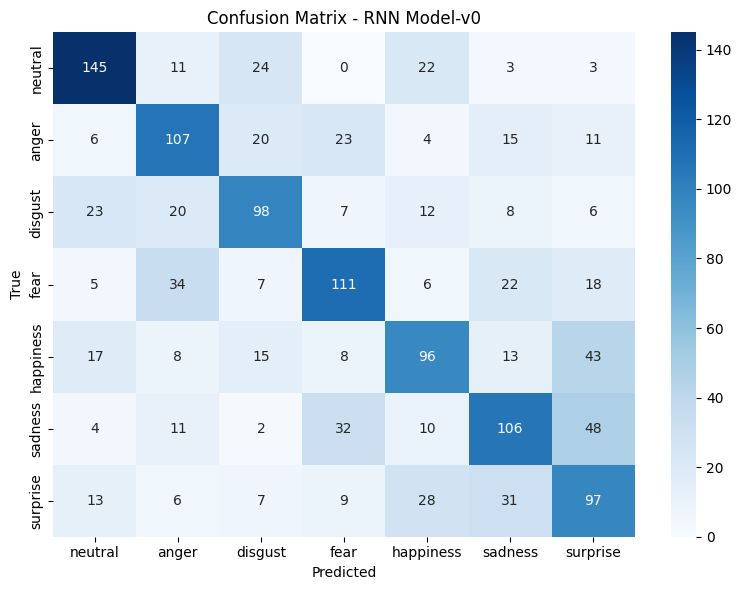

In [56]:
# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot heatmap
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[EMOTION_MAP[i] for i in range(len(EMOTION_MAP))],
            yticklabels=[EMOTION_MAP[i] for i in range(len(EMOTION_MAP))],
            ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_title('Confusion Matrix - RNN Model-v0')
plt.tight_layout()
plt.show()

#### Two recurrent layers

In [57]:
tokens_input = Input(shape=(30,), name="tokens_input")
x = Embedding(input_dim=V+1, output_dim=128)(tokens_input)
x = SimpleRNN(128, activation="tanh", return_sequences=True)(x)
x = SimpleRNN(128, activation="tanh", return_sequences=False)(x)  # final hidden state

# 4. Classification head
dense = Dense(64, activation="relu", kernel_regularizer="l2")(x)
dense = Dense(128, activation="relu", kernel_regularizer="l2")(dense)
dense = Dropout(0.4)(dense)
output = Dense(7, activation="softmax")(dense)

# 5. Build model
model = Model(inputs=tokens_input, outputs=output, name="SimpleRNN-v1")
model.compile(optimizer=Adam(learning_rate=1e-4), loss='categorical_crossentropy', metrics=['accuracy'])

In [58]:
try:
    model = load_model(r"keras-models\SimpleRNN-v1.keras")
except:
    # Monitors the validation loss and stops after 3 epochs with no improvement
    early_stopping = EarlyStopping(monitor='val_accuracy', patience=5, verbose=0, restore_best_weights=True)

    with device:
        history = model.fit(
            X_train_toks, y_train,
            validation_data=(X_test_toks, y_test),
            epochs=100,
            batch_size=64,
            verbose=0,
            callbacks=[early_stopping]
        )

In [59]:
# Evaluate the model on the test set
loss, accuracy = model.evaluate(X_test_toks, y_test, verbose=0)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

Test Loss: 2.1685
Test Accuracy: 0.5964


In [60]:
# Step 1: Get predictions
y_pred_probs = model.predict(X_test_toks)

# Step 2: Convert probabilities to class labels
y_pred = np.argmax(y_pred_probs, axis=1)

# Step 3: Convert y_test if it's one-hot encoded
if y_test.ndim > 1 and y_test.shape[1] > 1:
    y_true = np.argmax(y_test, axis=1)
else:
    y_true = y_test

predictions["SimpleRNN-v1"] = y_pred

# Step 4: Generate classification report
print(classification_report(y_true, y_pred, digits=3))

43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
              precision    recall  f1-score   support

           0      0.781     0.788     0.785       208
           1      0.508     0.527     0.517       186
           2      0.513     0.586     0.547       174
           3      0.610     0.586     0.598       203
           4      0.535     0.495     0.514       200
           5      0.551     0.582     0.566       213
           6      0.679     0.597     0.635       191

    accuracy                          0.596      1375
   macro avg      0.597     0.595     0.595      1375
weighted avg      0.599     0.596     0.597      1375



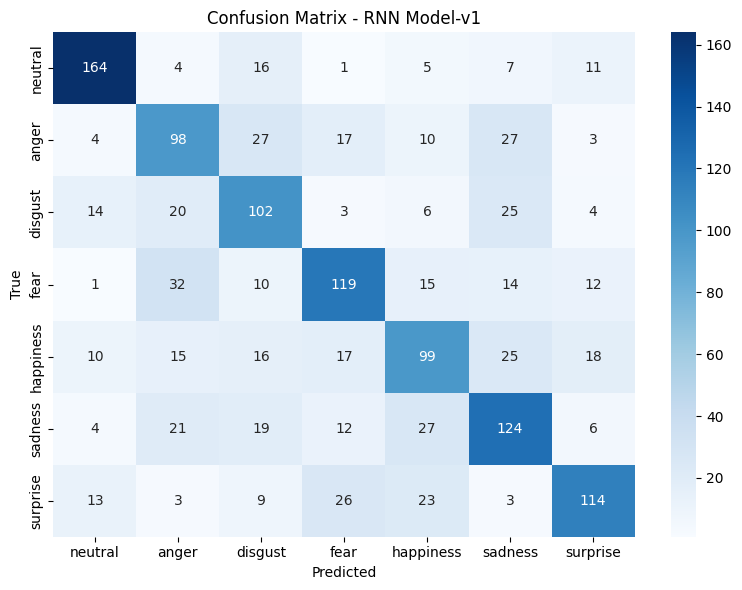

In [61]:
# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot heatmap
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[EMOTION_MAP[i] for i in range(len(EMOTION_MAP))],
            yticklabels=[EMOTION_MAP[i] for i in range(len(EMOTION_MAP))],
            ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_title('Confusion Matrix - RNN Model-v1')
plt.tight_layout()
plt.show()

### LSTM Model

#### One recurrent layer

In [62]:
tokens_input = Input(shape=(30,), name="tokens_input")
x = Embedding(input_dim=V+1, output_dim=128)(tokens_input)
x = LSTM(128, activation="tanh", return_sequences=False)(x)  # final hidden state
# 4. Classification head
dense = Dense(64, activation="relu", kernel_regularizer="l2")(x)
dense = Dense(128, activation="relu", kernel_regularizer="l2")(dense)
# dense = Dropout(0.4)(dense)
output = Dense(7, activation="softmax")(dense)

# 5. Build model
model = Model(inputs=tokens_input, outputs=output, name="LSTM-v0")
model.compile(optimizer=Adam(learning_rate=5e-3), loss='categorical_crossentropy', metrics=['accuracy'])

In [63]:
try:
    model = load_model(r"keras-models\LSTM-v0.keras")
except:
    # Monitors the validation loss and stops after 3 epochs with no improvement
    early_stopping = EarlyStopping(monitor='val_accuracy', patience=5, verbose=0, restore_best_weights=True)
    with device:
        history = model.fit(
            X_train_toks, y_train,
            validation_data=(X_test_toks, y_test),
            epochs=100,
            batch_size=64,
            verbose=0,
            callbacks=[early_stopping]
        )

In [64]:
# Evaluate the model on the test set
loss, accuracy = model.evaluate(X_test_toks, y_test, verbose=0)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

Test Loss: 2.3597
Test Accuracy: 0.7098


In [65]:
# Step 1: Get predictions
y_pred_probs = model.predict(X_test_toks)

# Step 2: Convert probabilities to class labels
y_pred = np.argmax(y_pred_probs, axis=1)

# Step 3: Convert y_test if it's one-hot encoded
if y_test.ndim > 1 and y_test.shape[1] > 1:
    y_true = np.argmax(y_test, axis=1)
else:
    y_true = y_test

predictions["LSTM-v0"] = y_pred

# Step 4: Generate classification report
print(classification_report(y_true, y_pred, digits=3))

43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
              precision    recall  f1-score   support

           0      0.864     0.731     0.792       208
           1      0.585     0.645     0.614       186
           2      0.652     0.603     0.627       174
           3      0.823     0.778     0.800       203
           4      0.530     0.660     0.588       200
           5      0.762     0.690     0.724       213
           6      0.814     0.848     0.831       191

    accuracy                          0.710      1375
   macro avg      0.719     0.708     0.711      1375
weighted avg      0.722     0.710     0.713      1375



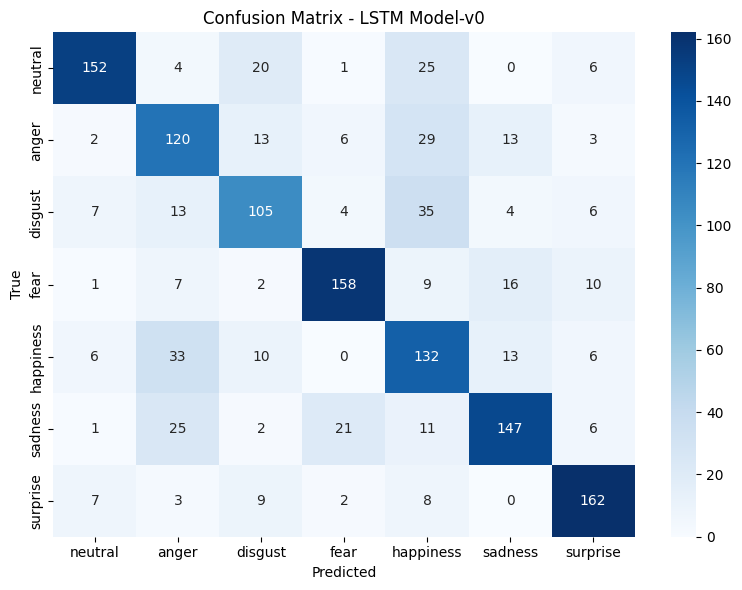

In [66]:
# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot heatmap
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[EMOTION_MAP[i] for i in range(len(EMOTION_MAP))],
            yticklabels=[EMOTION_MAP[i] for i in range(len(EMOTION_MAP))],
            ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_title('Confusion Matrix - LSTM Model-v0')
plt.tight_layout()
plt.show()

#### Two recurrent layers

In [67]:
tokens_input = Input(shape=(30,), name="tokens_input")
x = Embedding(input_dim=V+1, output_dim=128)(tokens_input)
x = LSTM(128, activation="tanh", return_sequences=True)(x)
x = LSTM(128, activation="tanh", return_sequences=False)(x)  # final hidden state
# 4. Classification head
dense = Dense(64, activation="relu", kernel_regularizer="l2")(x)
dense = Dense(128, activation="relu", kernel_regularizer="l2")(dense)
# dense = Dropout(0.4)(dense)
output = Dense(7, activation="softmax")(dense)

# 5. Build model
model = Model(inputs=tokens_input, outputs=output, name="LSTM-v1")
model.compile(optimizer=Adam(learning_rate=5e-3), loss='categorical_crossentropy', metrics=['accuracy'])

In [68]:
try:
    model = load_model(r"keras-models\LSTM-v1.keras")
except:
    # Monitors the validation loss and stops after 3 epochs with no improvement
    early_stopping = EarlyStopping(monitor='val_accuracy', patience=5, verbose=0, restore_best_weights=True)
    with device:
        history = model.fit(
            X_train_toks, y_train,
            validation_data=(X_test_toks, y_test),
            epochs=100,
            batch_size=64,
            verbose=0,
            callbacks=[early_stopping]
        )

In [69]:
# Evaluate the model on the test set
loss, accuracy = model.evaluate(X_test_toks, y_test, verbose=0)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

Test Loss: 1.2694
Test Accuracy: 0.7825


In [70]:
# Step 1: Get predictions
y_pred_probs = model.predict(X_test_toks)

# Step 2: Convert probabilities to class labels
y_pred = np.argmax(y_pred_probs, axis=1)

# Step 3: Convert y_test if it's one-hot encoded
if y_test.ndim > 1 and y_test.shape[1] > 1:
    y_true = np.argmax(y_test, axis=1)
else:
    y_true = y_test

predictions["LSTM-v1"] = y_pred

# Step 4: Generate classification report
print(classification_report(y_true, y_pred, digits=3))

43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step
              precision    recall  f1-score   support

           0      0.833     0.812     0.822       208
           1      0.617     0.753     0.678       186
           2      0.651     0.644     0.647       174
           3      0.946     0.783     0.857       203
           4      0.716     0.780     0.746       200
           5      0.846     0.826     0.836       213
           6      0.916     0.859     0.886       191

    accuracy                          0.783      1375
   macro avg      0.789     0.780     0.782      1375
weighted avg      0.794     0.783     0.786      1375



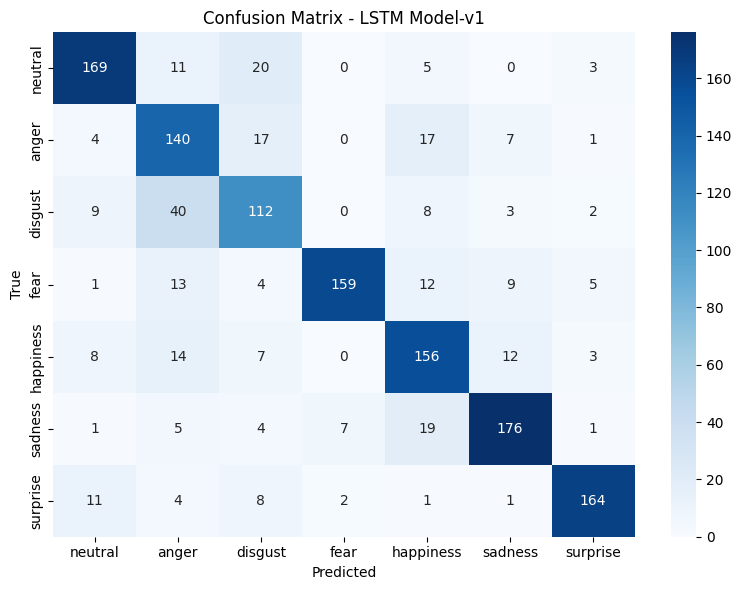

In [71]:
# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot heatmap
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[EMOTION_MAP[i] for i in range(len(EMOTION_MAP))],
            yticklabels=[EMOTION_MAP[i] for i in range(len(EMOTION_MAP))],
            ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_title('Confusion Matrix - LSTM Model-v1')
plt.tight_layout()
plt.show()

#### LSTM with additional features 

In [72]:
# 1. Text branch
tokens_input = Input(shape=(30,), name="tokens_input")
x = Embedding(input_dim=V+1, output_dim=128)(tokens_input)
x = LSTM(128, activation="tanh", return_sequences=True)(x)
x = LSTM(128, activation="tanh", return_sequences=False)(x)  # final hidden state

# 2. Extra features branch
features_input = Input(shape=(X_train_features.shape[1],), name="features_input")

# 3. Concatenate text + features
combined = Concatenate()([x, features_input])

# 4. Classification head
dense = Dropout(0.4)(combined)
dense = Dense(64, activation="relu", kernel_regularizer="l2")(dense)
dense = Dense(128, activation="relu", kernel_regularizer="l2")(dense)
output = Dense(7, activation="softmax")(dense)

# 5. Build model
model = Model(inputs=[tokens_input, features_input], outputs=output, name='LSTM-v2')
model.compile(optimizer=Adam(learning_rate=5e-3), loss='categorical_crossentropy', metrics=['accuracy'])

In [73]:
try:
    model = load_model(r"keras-models\LSTM-v2.keras")
except:
    # Monitors the validation loss and stops after 3 epochs with no improvement
    early_stopping = EarlyStopping(monitor='val_accuracy', patience=5, verbose=0, restore_best_weights=True)
    with device:
        history = model.fit(
            [X_train_toks, X_train_features], y_train,
            validation_data=([X_test_toks, X_test_features], y_test),
            epochs=100,
            batch_size=64,
            verbose=0,
            callbacks=[early_stopping]
        )

In [74]:
# Evaluate the model on the test set
loss, accuracy = model.evaluate([X_test_toks, X_test_features], y_test, verbose=0)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

Test Loss: 0.9629
Test Accuracy: 0.7905


In [75]:
# Step 1: Get predictions
y_pred_probs = model.predict([X_test_toks, X_test_features])

# Step 2: Convert probabilities to class labels
y_pred = np.argmax(y_pred_probs, axis=1)

# Step 3: Convert y_test if it's one-hot encoded
if y_test.ndim > 1 and y_test.shape[1] > 1:
    y_true = np.argmax(y_test, axis=1)
else:
    y_true = y_test

predictions["LSTM-v2"] = y_pred

# Step 4: Generate classification report
print(classification_report(y_true, y_pred, digits=3))

43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step
              precision    recall  f1-score   support

           0      0.829     0.793     0.811       208
           1      0.882     0.720     0.793       186
           2      0.610     0.799     0.692       174
           3      0.862     0.828     0.844       203
           4      0.727     0.800     0.762       200
           5      0.857     0.761     0.806       213
           6      0.828     0.832     0.830       191

    accuracy                          0.791      1375
   macro avg      0.799     0.790     0.791      1375
weighted avg      0.803     0.791     0.793      1375



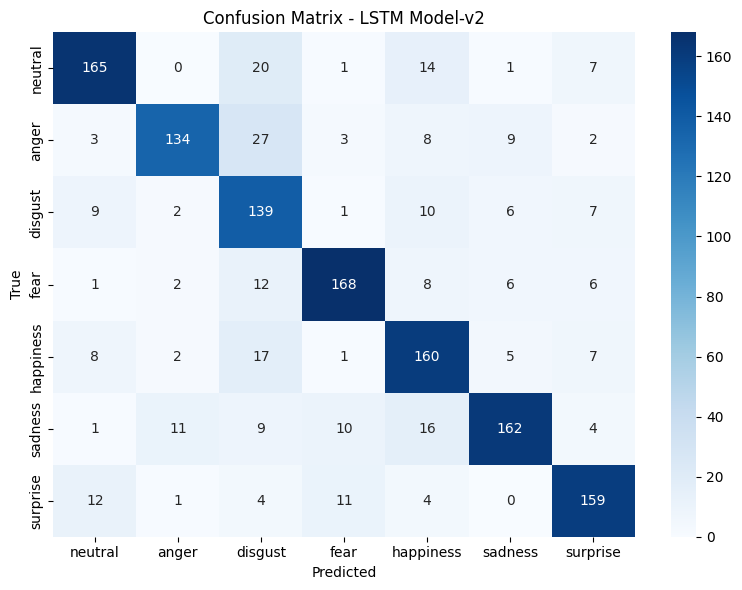

In [76]:
# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot heatmap
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[EMOTION_MAP[i] for i in range(len(EMOTION_MAP))],
            yticklabels=[EMOTION_MAP[i] for i in range(len(EMOTION_MAP))],
            ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_title('Confusion Matrix - LSTM Model-v2')
plt.tight_layout()
plt.show()

#### LSTM with BERT Embeddings 

In [77]:
# 1. Text branch
tokens_input = Input(shape=(30,), name="tokens_input")
x = Embedding(input_dim=V+1, output_dim=128)(tokens_input)
x = LSTM(128, activation="tanh", return_sequences=True)(x)
x = LSTM(128, activation="tanh", return_sequences=False)(x)  # final hidden state

bert_input = Input(shape=(768,), name='bert_input')
bert_proj = Dense(128, activation="relu")(bert_input)

features = Concatenate()([x, bert_proj])

# 4. Classification head
dense = Dropout(0.4)(features)
dense = Dense(128, activation="relu", kernel_regularizer="l2")(dense)
dense = Dense(128, activation="relu", kernel_regularizer="l2")(dense)
dense = Dense(128, activation="relu", kernel_regularizer="l2")(dense)
output = Dense(7, activation="softmax")(dense)

# 5. Build model
model = Model(inputs=[tokens_input, bert_input], outputs=output, name='LSTM-v3')
model.compile(optimizer=Adam(learning_rate=5e-3), loss='categorical_crossentropy', metrics=['accuracy'])

In [78]:
try:
    model = load_model(r"keras-models\LSTM-v3.keras")
except:
    # Monitors the validation loss and stops after 3 epochs with no improvement
    early_stopping = EarlyStopping(monitor='val_accuracy', patience=5, verbose=0, restore_best_weights=True)
    with device:
        history = model.fit(
            [X_train_toks, bert_train], y_train,
            validation_data=([X_test_toks, bert_test], y_test),
            epochs=100,
            batch_size=64,
            verbose=0,
            callbacks=[early_stopping]
        )

In [79]:
# Evaluate the model on the test set
loss, accuracy = model.evaluate([X_test_toks, bert_test], y_test, verbose=0)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

Test Loss: 1.0919
Test Accuracy: 0.7964


In [80]:
# Step 1: Get predictions
y_pred_probs = model.predict([X_test_toks, bert_test])

# Step 2: Convert probabilities to class labels
y_pred = np.argmax(y_pred_probs, axis=1)

# Step 3: Convert y_test if it's one-hot encoded
if y_test.ndim > 1 and y_test.shape[1] > 1:
    y_true = np.argmax(y_test, axis=1)
else:
    y_true = y_test

predictions["LSTM-v3"] = y_pred

# Step 4: Generate classification report
print(classification_report(y_true, y_pred, digits=3))

43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step
              precision    recall  f1-score   support

           0      0.842     0.846     0.844       208
           1      0.826     0.742     0.782       186
           2      0.699     0.736     0.717       174
           3      0.921     0.808     0.861       203
           4      0.635     0.800     0.708       200
           5      0.820     0.770     0.794       213
           6      0.887     0.864     0.875       191

    accuracy                          0.796      1375
   macro avg      0.804     0.795     0.797      1375
weighted avg      0.806     0.796     0.799      1375



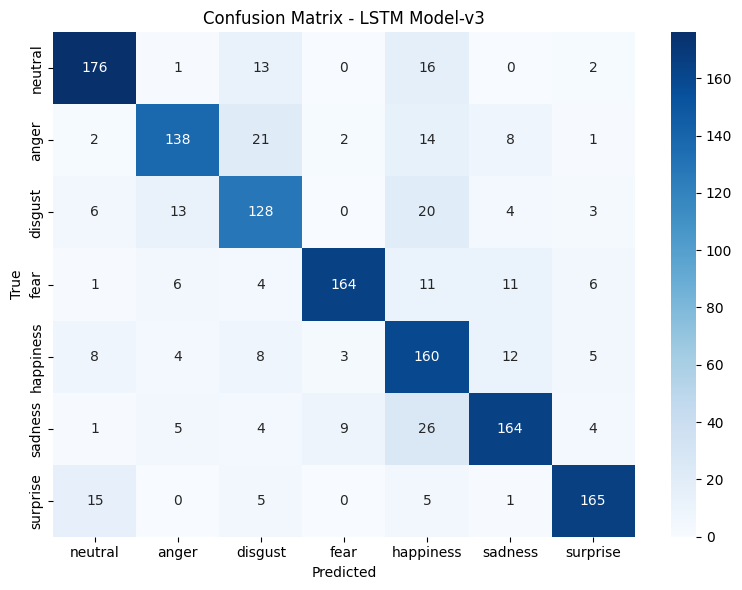

In [81]:
# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot heatmap
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[EMOTION_MAP[i] for i in range(len(EMOTION_MAP))],
            yticklabels=[EMOTION_MAP[i] for i in range(len(EMOTION_MAP))],
            ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_title('Confusion Matrix - LSTM Model-v3')
plt.tight_layout()
plt.show()

In [82]:
TRUE_KERAS = y_true
KERAS_TEST = X_test

### Error analysis on Keras models

In [83]:
keras_models = ["SimpleRNN-v0", "SimpleRNN-v1", "LSTM-v0", "LSTM-v1", "LSTM-v2", "LSTM-v3"]

for model_name, y_pred in predictions.items():
    if model_name in keras_models:
        f1 = f1_score(TRUE_KERAS, y_pred, average='weighted')  # keras y_test
    elif model_name in sklearn_models:
        continue
    else:
        raise ValueError(f"Unknown model name: {model_name}.")
    
    print(f"The {model_name} model yielded a weighted F1 score of: {f1:.3f}")


The SimpleRNN-v0 model yielded a weighted F1 score of: 0.553
The SimpleRNN-v1 model yielded a weighted F1 score of: 0.597
The LSTM-v0 model yielded a weighted F1 score of: 0.713
The LSTM-v1 model yielded a weighted F1 score of: 0.786
The LSTM-v2 model yielded a weighted F1 score of: 0.793
The LSTM-v3 model yielded a weighted F1 score of: 0.799


In [84]:
keras_results, keras_common_errors = error_analysis(predictions, keras_models, KERAS_TEST, TRUE_KERAS, EMOTION_MAP)

print("\nKeras models error stats:")
for model in keras_models:
    if model in keras_results:
        stats = keras_results[model]
        print(f"{model}: {stats['num_errors']} errors out of {stats['total']} ({stats['error_rate']:.2%})")

print("\nMost common keras mistakes (true → predicted):")
for item in keras_common_errors:
    print(item)



Keras models error stats:
SimpleRNN-v0: 615 errors out of 1375 (44.73%)
SimpleRNN-v1: 555 errors out of 1375 (40.36%)
LSTM-v0: 399 errors out of 1375 (29.02%)
LSTM-v1: 299 errors out of 1375 (21.75%)
LSTM-v2: 288 errors out of 1375 (20.95%)
LSTM-v3: 280 errors out of 1375 (20.36%)

Most common keras mistakes (true → predicted):
(('anger', 'disgust'), 125)
(('neutral', 'disgust'), 113)
(('sadness', 'happiness'), 109)
(('disgust', 'anger'), 108)
(('fear', 'anger'), 94)
(('sadness', 'fear'), 91)
(('disgust', 'happiness'), 91)
(('neutral', 'happiness'), 87)
(('anger', 'happiness'), 82)
(('happiness', 'surprise'), 82)


- **RNN Model** 

    - Two models were developed using the Keras Functional API with the SimpleRNN recurrent layer. The first model included a single recurrent layer, while the second used two recurrent layers. The assumption was that the model with two recurrent layers would capture linguistic patterns more effectively, thereby improving emotion differentiation.  

    - This assumption was validated by our experiments, as the two-layer model outperformed the single-layer one. The first model, named `"SimpleRNN-v0"`, achieved a weighted F1 score of **0.553** or **55.3%**, while the two-layer model, named `"SimpleRNN-v1"`, reached **0.597** or **59.7%**. The approximately **5%** improvement in performance clearly showed the benefit of an additional recurrent layer.  

    - After experimentation with layer normalization, dropout rates, and learning rates, the following parameters were identified as optimal for the SimpleRNN models: `lr=1e-4`, `kernel_regularizer="l2"` for the dense layers, `batch_size=64`, and a `(0.4)` dropout layer before the classification head.  

    - The weighted F1 score of about **60%** demonstrated that, with suitable parameters and architecture, the model could distinguish between emotions decently.  

    - The best performance was achieved for the *neutral* class, with an F1-score of around **79%**. The other emotion classes scored between **51–64%**.  

    - The weakest performing classes were ***anger, happiness, and disgust***. **Anger** was often misclassified as *disgust* or *sadness*, **disgust** was distributed across *sadness*, *anger*, and *neutral*, and **happiness** was most often mistaken for *sadness*, with similar misclassification patterns across other classes.  


- **LSTM Model**  

    - Similarly, two models were constructed using the Keras Functional API with the LSTM layer. The first model had one recurrent layer, while the second used two. Theass umption was again that additional recurrent layers would better capture linguistic structures and improve emotion differentiation. The two-layer LSTM model confirmed this assumption again by outperforming the single-layer one.  

    - The first model, named `"LSTM-v0"`, achieved a weighted F1 score of **0.713** or **71.3%**, while the two-layer model, named `"LSTM-v1"`, reached **0.786** or **78.6%**, marking an improvement of about **7%**.  

    - After experimenting with layer normalization, dropout rates, and learning rates, the best parameters for the LSTM models were determined to be: `lr=5e-3`, `kernel_regularizer="l2"` for the dense layers, and `batch_size=64`.  

    - We also tested additional features obtained from the NLP Feature Extraction task. Specifically, we combined Word2Vec and BERT embeddings with the self-generated embeddings in the `"LSTM-v2"` model. This approach slightly improved performance by about **0.5%**, although we suspected that stacking these features might have introduced confusion for the model.  

    - Based on this observation, we refined the approach by providing only one additional feature — the **BERT embeddings**. These embeddings were first projected through a dense layer, then concatenated with the LSTM outputs. This design was tested in the `"LSTM-v3"` model. Initially, the model struggled, so we added an additional dense layer, resulting in a three-layer dense head with 128 neurons each. This adjustment led to another small improvement of about **0.5%**, suggesting that the models were approaching their performance limit.  

    - Ultimately, the best model achieved a weighted F1 score of approximately **80%**, indicating a strong ability to capture linguistic nuances and differentiate between emotions. This was also the first model to surpass the **75% F1-score threshold**, meeting the minimum benchmark requirement.  

    - The best-performing emotion was *surpise*, with other well performing emotion being *neutral*, *sadness*, *fear*, and *happiness*.  

    - Despite overall good performance, some issues remain. The model struggled with correctly identifying *disgust*, frequently confusing it with *anger* — and vice versa. While these emotions can overlap, this remains a notable limitation.  


*Keras overall statistics*  

After extensive experimentation, the best weighted F1 scores achieved were **60% for RNN** and **80% for LSTM**. Most errors involved *anger* being misclassified as *disgust*, with more than **100 errors**.

With the performance of the LSTM models beginning to plateau, even after the inclusion of additional features, we believe we have reached the limits of what these architectures can achieve. Consequently, our next step will be to explore **Transformer-based models**, as their innovative architecture may further enhance our modeling capabilities and lead to improved performance.


## Transformer Models 

In [85]:
# Balance dataset (you can adjust n=5000)
transformers_data = []
unique_emotions = df_concat['Emotion'].unique()

for emotion in unique_emotions:
    emotion_rows = df_concat[df_concat['Emotion'] == emotion]
    sampled_rows = emotion_rows.sample(n=5000, replace=True, random_state=42)
    transformers_data.append(sampled_rows)

transformers_data = pd.concat(transformers_data, ignore_index=True)
transformers_data['Emotion_ID'] = transformers_data['Emotion_ID'].astype(int)
transformers_data = transformers_data.drop(columns=['Unnamed: 0', 'Emotion'], errors='ignore')

In [86]:
X_train, X_test, y_train, y_test = train_test_split(
    transformers_data['Sentence'],
    transformers_data['Emotion_ID'],
    test_size=0.2,
    random_state=42,
    stratify=transformers_data['Emotion_ID']
)

In [87]:
# Data Preparation & Tokenization
def tokenize_data(checkpoint, X_train, y_train, X_test, y_test):
    tokenizer = AutoTokenizer.from_pretrained(checkpoint)

    def tokenize_function(example):
        return tokenizer(example["text"], truncation=True, padding="max_length", max_length=128)

    train_df = pd.DataFrame({"text": X_train, "label": y_train})
    test_df = pd.DataFrame({"text": X_test, "label": y_test})

    train_dataset = Dataset.from_pandas(train_df)
    test_dataset = Dataset.from_pandas(test_df)

    tokenized_train = train_dataset.map(tokenize_function, batched=True)
    tokenized_test = test_dataset.map(tokenize_function, batched=True)

    data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

    return tokenizer, tokenized_train, tokenized_test, data_collator

In [88]:
# Model Config & Training Setup
def create_model_and_config(checkpoint, num_labels=7):
    config = AutoConfig.from_pretrained(checkpoint, num_labels=num_labels)
    model = AutoModelForSequenceClassification.from_pretrained(
        checkpoint,
        config=config,
        ignore_mismatched_sizes=True
    )
    return model

def create_training_args():
    return TrainingArguments(
        output_dir="./transformer-outputs",
        eval_strategy="epoch",
        save_strategy="epoch",
        learning_rate=2e-5,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=16,
        num_train_epochs=5,
        weight_decay=0.01,
        load_best_model_at_end=True,
        metric_for_best_model="accuracy",
        logging_dir="./logs",
        logging_steps=50
    )

In [89]:
# Evaluation Metrics
def compute_metrics(eval_pred):
    accuracy_metric = evaluate.load("accuracy")
    f1_metric = evaluate.load("f1")

    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)

    acc = accuracy_metric.compute(predictions=predictions, references=labels)
    f1 = f1_metric.compute(predictions=predictions, references=labels, average="weighted")

    return {"accuracy": acc["accuracy"], "f1_weighted": f1["f1"]}

In [90]:
# Trainer Setup
def setup_trainer(model, tokenizer, training_args, train_set, test_set, data_collator):
    return Trainer(
        model=model,
        args=training_args,
        train_dataset=train_set,
        eval_dataset=test_set,
        processing_class=tokenizer,
        data_collator=data_collator,
        compute_metrics=compute_metrics,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=3)]
    )

In [91]:
def load_or_train_model(base_checkpoint, fallback_checkpoint,
                        X_train, y_train, X_test, y_test):
    
    model_exists = os.path.exists(base_checkpoint)

    try:
        print(f"Loading tokenizer and model from {base_checkpoint}...")
        tokenizer, train_ds, test_ds, collator = tokenize_data(base_checkpoint, X_train, y_train, X_test, y_test)
        model = AutoModelForSequenceClassification.from_pretrained(base_checkpoint)
    except OSError:
        print(f"Failed to load {base_checkpoint}, falling back to {fallback_checkpoint}...")
        tokenizer, train_ds, test_ds, collator = tokenize_data(fallback_checkpoint, X_train, y_train, X_test, y_test)
        model = create_model_and_config(fallback_checkpoint)

    if model_exists:
        training_args = create_training_args()
        trainer = setup_trainer(model, tokenizer, training_args, train_ds, test_ds, collator)
    else:
        # Train new model
        print("Training new model...")
        training_args = create_training_args()
        trainer = setup_trainer(model, tokenizer, training_args, train_ds, test_ds, collator)
        trainer.train()

        # Save the model and tokenizer
        print(f"Saving trained model to {base_checkpoint}...")
        trainer.save_model(base_checkpoint)

    return model, tokenizer, trainer, train_ds, test_ds
    

### DistilBERT base model (uncased)

In [92]:
checkpoint = "transformer-models/distilbert-base"
fallback = "distilbert-base-uncased-finetuned-sst-2-english"

model, tokenizer, trainer, train_ds, test_ds = load_or_train_model(
    base_checkpoint=checkpoint,
    fallback_checkpoint=fallback,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test
)

Loading tokenizer and model from transformer-models/distilbert-base...


Map: 100%|██████████| 7000/7000 [00:00<00:00, 11651.18 examples/s]


In [93]:
preds = trainer.predict(test_ds)
y_pred = np.argmax(preds.predictions, axis=-1)
y_true = np.array(test_ds["label"])

predictions["DistilBERT-base-uncased"] = y_pred

print(classification_report(y_true, y_pred, digits=3))

              precision    recall  f1-score   support

           0      0.824     0.860     0.841      1000
           1      0.888     0.862     0.875      1000
           2      0.812     0.860     0.835      1000
           3      0.931     0.872     0.900      1000
           4      0.925     0.901     0.913      1000
           5      0.956     0.915     0.935      1000
           6      0.899     0.951     0.924      1000

    accuracy                          0.889      7000
   macro avg      0.891     0.889     0.889      7000
weighted avg      0.891     0.889     0.889      7000



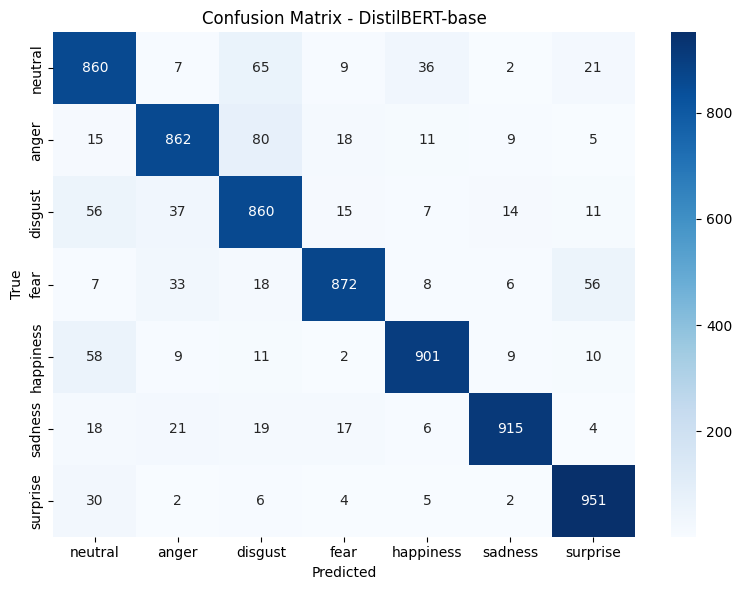

In [94]:
# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot heatmap
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[EMOTION_MAP[i] for i in range(len(EMOTION_MAP))],
            yticklabels=[EMOTION_MAP[i] for i in range(len(EMOTION_MAP))],
            ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_title('Confusion Matrix - DistilBERT-base')
plt.tight_layout()
plt.show()

### BERT base model (uncased)

In [95]:
checkpoint = "transformer-models/bert-base"
fallback = "bert-base-uncased"

model, tokenizer, trainer, train_ds, test_ds = load_or_train_model(
    base_checkpoint=checkpoint,
    fallback_checkpoint=fallback,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test
)

Loading tokenizer and model from transformer-models/bert-base...


Map: 100%|██████████| 7000/7000 [00:00<00:00, 10785.56 examples/s]


In [96]:
preds = trainer.predict(test_ds)
y_pred = np.argmax(preds.predictions, axis=-1)
y_true = np.array(test_ds["label"])

predictions["BERT-base-uncased"] = y_pred

print(classification_report(y_true, y_pred, digits=3))

              precision    recall  f1-score   support

           0      0.818     0.901     0.857      1000
           1      0.928     0.841     0.882      1000
           2      0.833     0.868     0.850      1000
           3      0.944     0.881     0.912      1000
           4      0.935     0.891     0.912      1000
           5      0.912     0.935     0.923      1000
           6      0.910     0.946     0.928      1000

    accuracy                          0.895      7000
   macro avg      0.897     0.895     0.895      7000
weighted avg      0.897     0.895     0.895      7000



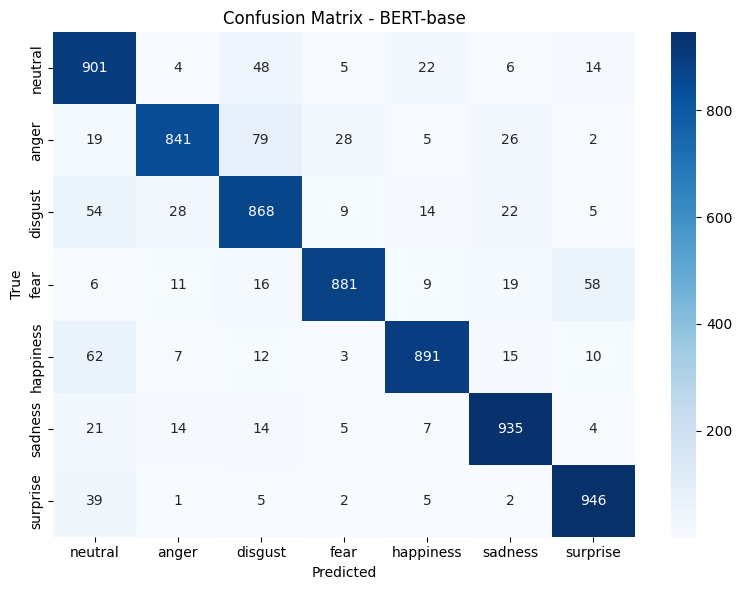

In [97]:
# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot heatmap
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[EMOTION_MAP[i] for i in range(len(EMOTION_MAP))],
            yticklabels=[EMOTION_MAP[i] for i in range(len(EMOTION_MAP))],
            ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_title('Confusion Matrix - BERT-base')
plt.tight_layout()
plt.show()

In [98]:
TRANSF_TEST = pd.DataFrame(X_test)
TRUE_TRANSF = y_true

In [99]:
transformer_models = ["DistilBERT-base-uncased", "BERT-base-uncased"]

for model_name, y_pred in predictions.items():
    if model_name in transformer_models:
        f1 = f1_score(TRUE_TRANSF, y_pred, average='weighted')
    elif model_name in sklearn_models or keras_models:
        continue
    else:
        raise ValueError(f"Unknown model name: {model_name}.")
    
    print(f"The {model_name} model yielded a weighted F1 score of: {f1:.3f}")


The DistilBERT-base-uncased model yielded a weighted F1 score of: 0.889
The BERT-base-uncased model yielded a weighted F1 score of: 0.895


In [100]:
tsf_results, tsf_common_errors = error_analysis(predictions, transformer_models, TRANSF_TEST, TRUE_TRANSF, EMOTION_MAP)

# Display results in defined order
print("Transformer Models error stats:")
for model in transformer_models:
    if model in tsf_results:
        stats = tsf_results[model]
        print(f"{model}: {stats['num_errors']} errors out of {stats['total']} ({stats['error_rate']:.2%})")

print("\nMost common Transformer Models mistakes (true → predicted):")
for item in tsf_common_errors:
    print(item)

Transformer Models error stats:
DistilBERT-base-uncased: 779 errors out of 7000 (11.13%)
BERT-base-uncased: 737 errors out of 7000 (10.53%)

Most common Transformer Models mistakes (true → predicted):
(('anger', 'disgust'), 159)
(('happiness', 'neutral'), 120)
(('fear', 'surprise'), 114)
(('neutral', 'disgust'), 113)
(('disgust', 'neutral'), 110)
(('surprise', 'neutral'), 69)
(('disgust', 'anger'), 65)
(('neutral', 'happiness'), 58)
(('anger', 'fear'), 46)
(('fear', 'anger'), 44)


## Testing the best models 

In [101]:
df_test = pd.read_csv(r'../Data/CSV/final_transcript.csv')

In [102]:
EMOTION_REVERSE_MAP = {v: k for k, v in EMOTION_MAP.items()}

In [103]:
# def make_keras_data(df_test):
#     features = FeatureEngine(custom_embeddings_path=r'..\Data\CSV\Yelp Restaurant Reviews.csv')
#     keras_df = features.create_features(transcript_df_input=df_test, output_path=None)
#     columns_to_keep = ['Sentence', 'Emotion_core', 'bert_embedding']
#     keras_df = keras_df[columns_to_keep]

#     X = keras_df.drop(columns=['Emotion_core'])
#     y = keras_df['Emotion_core'].map(EMOTION_REVERSE_MAP)

#     with open('artifacts/keras_tok/tokenizer.json', 'r', encoding='utf-8') as f:
#         loaded_tokenizer_json_str = f.read()
#     inner_tokenizer_json_str = json.loads(loaded_tokenizer_json_str)

#     tokenizer = tokenizer_from_json(inner_tokenizer_json_str)
#     keras_toks = tokenizer.texts_to_sequences(X['Sentence'])
#     keras_pads = pad_sequences(keras_toks, padding='post', maxlen=30)

#     X['Sentence_Tok'] = list(keras_pads)
#     y = to_categorical(y, num_classes=7)

#     return X, y

# X, y = make_keras_data(df_test)

# input_toks = X['Sentence_Tok']
# input_toks = np.array(input_toks.tolist())

# input_bert = normalize(np.stack(X["bert_embedding"].to_numpy()))

In [104]:
features = FeatureEngine(custom_embeddings_path=r'..\Data\CSV\Yelp Restaurant Reviews.csv')

keras_df = features.create_features(transcript_df_input=df_test, output_path=None)

In [105]:
columns_to_keep = ['Sentence', 'Emotion_core', 'bert_embedding']
keras_df = keras_df[columns_to_keep]

In [106]:
X = keras_df.drop(columns=['Emotion_core'])
y = keras_df['Emotion_core'].map(EMOTION_REVERSE_MAP)

In [107]:
# 1. Load the raw, double-serialized JSON string
with open('artifacts/keras_tok/tokenizer.json', 'r', encoding='utf-8') as f:
    loaded_tokenizer_json_str = f.read()

# 2. Deserialize the outer JSON string to get the inner JSON string
# This is the first deserialization, reversing the 'json.dumps' used in saving.
inner_tokenizer_json_str = json.loads(loaded_tokenizer_json_str)

# 3. Recreate the Tokenizer object
# This is the second deserialization, reversing the 'tokenizer.to_json()' used in saving.
tokenizer = tokenizer_from_json(inner_tokenizer_json_str)

print("Tokenizer loaded successfully.")

Tokenizer loaded successfully.


In [108]:
V = len(tokenizer.word_index)
V

9924

In [109]:
keras_toks = tokenizer.texts_to_sequences(X['Sentence'])

In [110]:
keras_pads = pad_sequences(keras_toks,
              padding='post',
              maxlen=30)

In [111]:
y = to_categorical(y, num_classes=7)

In [112]:
X['Sentence_Tok'] = list(keras_pads)

In [113]:
input_toks = X['Sentence_Tok']
input_toks = np.array(input_toks.tolist())

In [114]:
input_bert = normalize(np.stack(X["bert_embedding"].to_numpy()))

In [115]:
lstmv3 = load_model(r"keras-models\LSTM-v3.keras")

In [116]:
# Step 1: Get predictions
y_pred_probs = lstmv3.predict([input_toks, input_bert])

# Step 2: Convert probabilities to class labels
y_pred = np.argmax(y, axis=1)

# Step 3: Convert y_test if it's one-hot encoded
if y.ndim > 1 and y.shape[1] > 1:
    y_true = np.argmax(y, axis=1)
else:
    y_true = y

# Step 4: Generate classification report
print(classification_report(y_true, y_pred, digits=3))

39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step
              precision    recall  f1-score   support

           0      1.000     1.000     1.000       472
           1      1.000     1.000     1.000       106
           2      1.000     1.000     1.000        62
           3      1.000     1.000     1.000        69
           4      1.000     1.000     1.000       247
           5      1.000     1.000     1.000       164
           6      1.000     1.000     1.000       107

    accuracy                          1.000      1227
   macro avg      1.000     1.000     1.000      1227
weighted avg      1.000     1.000     1.000      1227



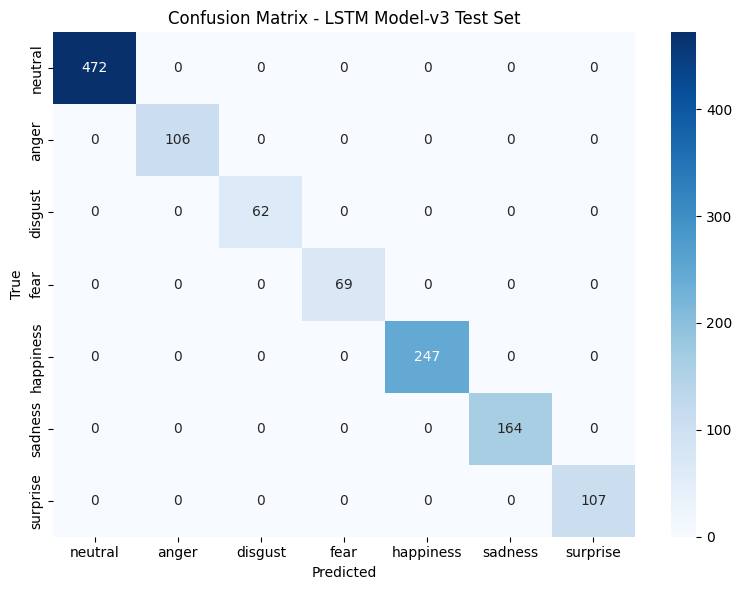

In [117]:
# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot heatmap
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[EMOTION_MAP[i] for i in range(len(EMOTION_MAP))],
            yticklabels=[EMOTION_MAP[i] for i in range(len(EMOTION_MAP))],
            ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_title('Confusion Matrix - LSTM Model-v3 Test Set')
plt.tight_layout()
plt.show()

In [118]:
columns_to_keep = ["Sentence", "Emotion_core"]

transformers_data = df_test[columns_to_keep].copy()

# Now safely map the labels
transformers_data["Emotion_core"] = transformers_data["Emotion_core"].map(EMOTION_REVERSE_MAP)

In [119]:
X, y = transformers_data['Sentence'], transformers_data['Emotion_core']

In [120]:
distilbert_base = "transformer-models/distilbert-base"
bert_base = "transformer-models/bert-base"

In [121]:
models = [distilbert_base, bert_base]
predictions = {}

for model in models:
    # 1. Split the string by '/'
    parts = model.split('/')
    
    # 2. Get the last part, which is the model name (e.g., 'distilbert-base')
    model_name = parts[-1] 
    
    # Initialize and Run PredictEngine
    engine = PredictEngine(
        checkpoint=model,
        data_source=transformers_data,
        column="Sentence"
    )
    
    # Use the extracted model_name as the key in the predictions dictionary
    predictions[model_name] = engine.predict()

Map: 100%|██████████| 1227/1227 [00:00<00:00, 24583.16 examples/s]


Map: 100%|██████████| 1227/1227 [00:00<00:00, 18902.28 examples/s]


In [122]:
y_true = np.array(y)

for model_name, y_pred in predictions.items():
    print(f'--- Results for {model_name} ---')
    
    # 1. Calculate F1 Score
    f1 = f1_score(y_true, y_pred, average='weighted')
    
    # 2. Calculate Accuracy Score
    accuracy = accuracy_score(y_true, y_pred)
    
    print(f"The F1 score for the {model_name} model is {f1:.3f}")
    print(f"The accuracy for the {model_name} model is {accuracy:.3f}")

--- Results for distilbert-base ---
The F1 score for the distilbert-base model is 0.438
The accuracy for the distilbert-base model is 0.511
--- Results for bert-base ---
The F1 score for the bert-base model is 0.382
The accuracy for the bert-base model is 0.481
